# Assignment 2: Combined Cycle Power Plant Data Set

Name: *Pratham Aggarwal* | Github: *prathamaeron* | USC ID: *1537722913*

## Importing the Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from itertools import combinations

## Exploring the Data

(i) From a look at Folds5x2_pp.xlsx, we can see that there are 5 columns and 9568 rows. The columns represent the hourly ambient variables: Temperature (AT), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V). These 4 variables are use to predict the net hourly electrical energy output (PE) of the plant. Below, I have imported this data.

In [2]:
data = pd.read_excel("../data/Folds5x2_pp.xlsx")
data.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


(ii) Make pairwise scatterplots of all variables in the data set including the predictors (independent variables) with the dependent variable. Describe your findings.

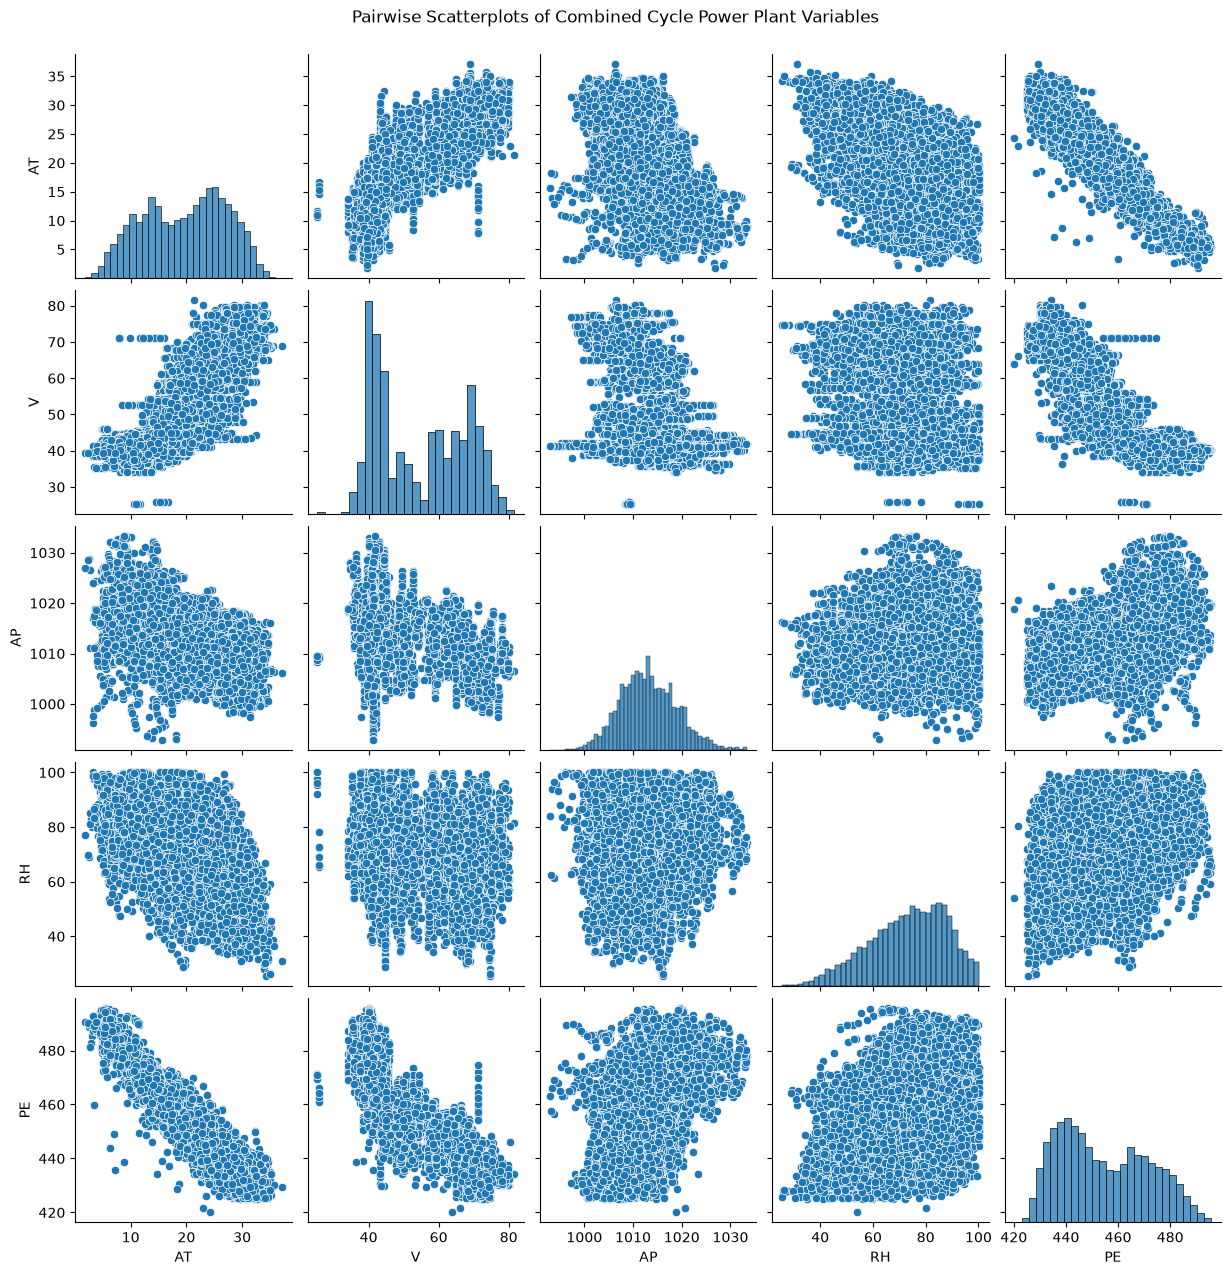

In [3]:
sns.pairplot(data, diag_kind="hist")
plt.suptitle("Pairwise Scatterplots of Combined Cycle Power Plant Variables", y=1.02)
plt.show()

The scatterplots show that PE has a strong negative relationship with AT and V. PE also has a weaker negative relationship with RH and a moderate positive relationship with AP. AT and V appear to have a strong positive relationship. The relationships between the remaining predictor variables are comparatively weaker. The diagonal histograms show the distributions of each variable.

(iii) What are the mean, the median, range, first and third quartiles, and interquartile ranges of each of the variables in the dataset? Summarize them in a table.

In [4]:
summary = data.describe().T

summary["range"] = summary["max"] - summary["min"]
summary["IQR"] = summary["75%"] - summary["25%"]

summary = summary.rename(columns={
    "mean": "Mean",
    "50%": "Median",
    "min": "Minimum",
    "max": "Maximum",
    "25%": "Q1",
    "75%": "Q3"
})

summary[["Mean", "Median", "Minimum", "Maximum", "range", "Q1", "Q3", "IQR"]].round(2)

,Mean,Median,Minimum,Maximum,range,Q1,Q3,IQR
AT,19.65,20.34,1.81,37.11,35.30,13.51,25.72,12.21
V,54.31,52.08,25.36,81.56,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,992.89,1033.30,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,25.56,100.16,74.60,63.33,84.83,21.50
PE,454.37,451.55,420.26,495.76,75.50,439.75,468.43,28.68


## Simple Linear Regression Model

(c) For each predictor, fit a simple linear regression model to predict the response. Describe your results. In which of the models is there a statistically significant association between the predictor and the response? Create some plots to back up your assertions. Are there any outliers that you would like to remove from your data for each of these regression tasks?

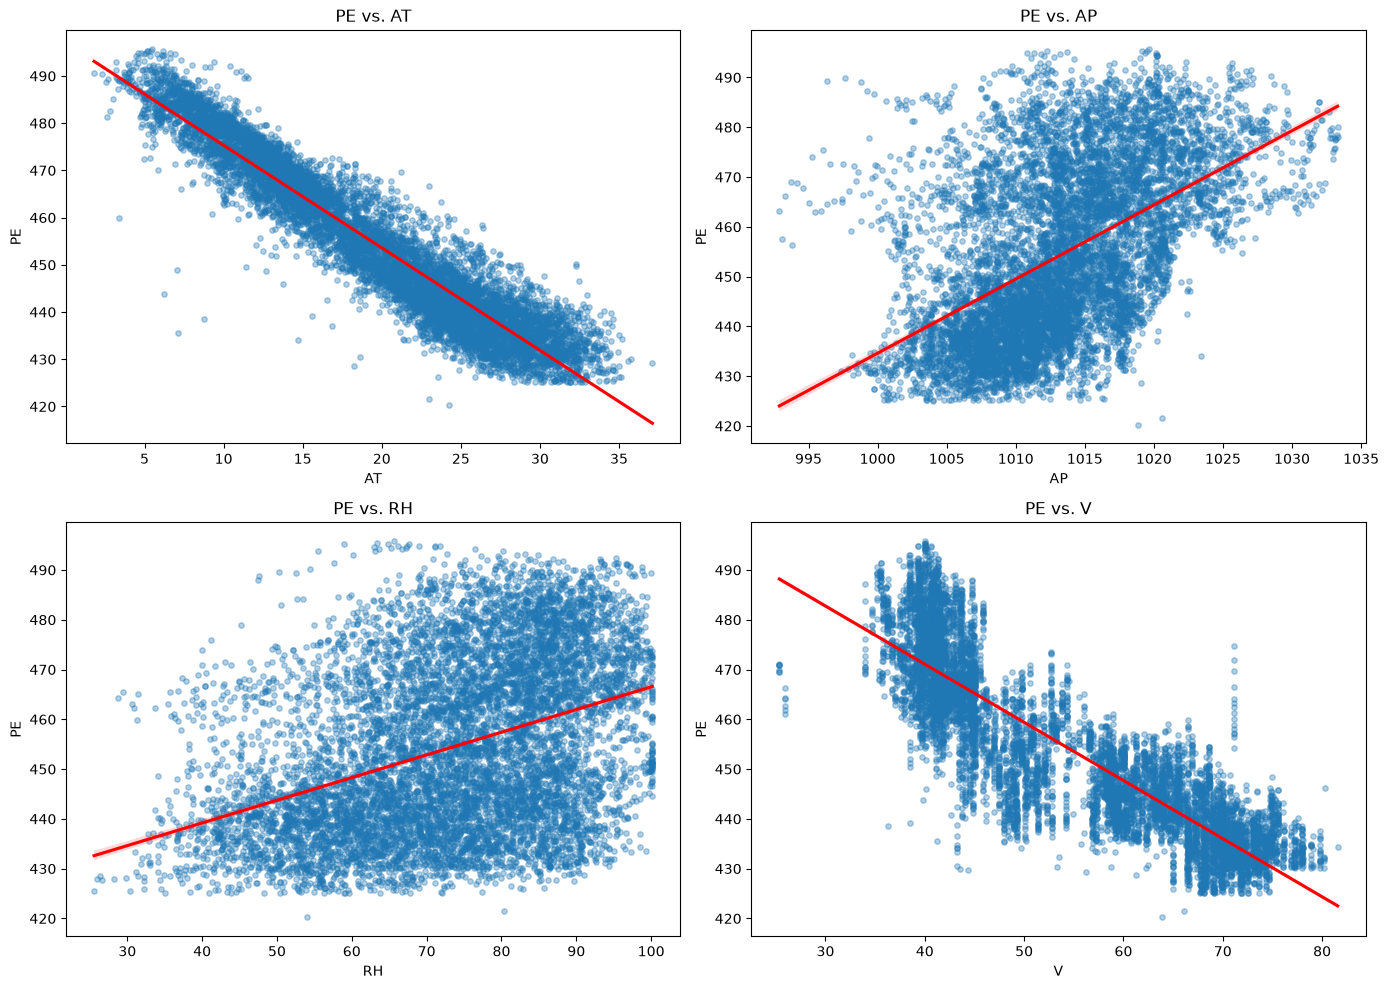

,Predictor,Intercept,Slope,R-squared,p-value,Outliers (|studentized residual| > 3)
0,AT,497.0341,-2.1713,0.8989,0.0,42
1,AP,-1055.2610,1.4899,0.2688,0.0,29
2,RH,420.9618,0.4557,0.1519,0.0,2
3,V,517.8015,-1.1681,0.7565,0.0,33


In [5]:
predictors = ["AT", "AP", "RH", "V"]
response = "PE"
results = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, predictor in zip(axes, predictors):
    X = sm.add_constant(data[predictor])
    y = data[response]

    model = sm.OLS(y, X).fit()
    influence = model.get_influence()
    studentized_residuals = influence.resid_studentized_internal
    outliers = np.abs(studentized_residuals) > 3

    results.append({
        "Predictor": predictor,
        "Intercept": model.params["const"],
        "Slope": model.params[predictor],
        "R-squared": model.rsquared,
        "p-value": model.pvalues[predictor],
        "Outliers (|studentized residual| > 3)": outliers.sum()
    })

    sns.regplot(
        x=data[predictor],
        y=data[response],
        ax=ax,
        scatter_kws={"alpha": 0.35, "s": 15},
        line_kws={"color": "red"}
    )
    ax.set_title(f"PE vs. {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")

plt.tight_layout()
plt.show()

regression_results = pd.DataFrame(results)
regression_results.round(4)

Each predictor was used separately to fit a simple linear regression model for predicting PE. The regression plots show that AT and V have strong negative linear associations with PE. RH has a weaker negative association, while AP has a weak positive association.

Because the sample size is large, all four predictors have statistically significant associations with PE at the 5% significance level (p-value < 0.05). However, statistical significance does not imply that all predictors have equally strong predictive power. The R-squared values indicate that AT and V explain substantially more variation in PE than AP and RH.

Potential outliers were identified using internally studentized residuals with an absolute value greater than 3. These observations should be investigated, but they were not removed because they may represent valid operating conditions of the power plant.

## Multiple Regression Model


(d) Fit a multiple regression model to predict the response using all of the predictors. Describe your results. For which predictors can we reject the null hypothesis $H_0 : \beta_j = 0$?


In [6]:
X = sm.add_constant(data[["AT", "AP", "RH", "V"]])
y = data["PE"]

multiple_model = sm.OLS(y, X).fit()

print(multiple_model.summary())

multiple_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "p-value": multiple_model.pvalues,
    "Significant at 5%": multiple_model.pvalues < 0.05
})

multiple_results.round(6)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        02:08:08   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

,Coefficient,p-value,Significant at 5%
const,454.609274,0.0,True
AT,-1.977513,0.0,True
AP,0.062083,0.0,True
RH,-0.158054,0.0,True
V,-0.233916,0.0,True


The multiple regression model uses AT, AP, RH, and V simultaneously to predict PE. The model explains approximately 93% of the variation in PE, indicating a strong overall fit.

The estimated coefficients for AT, RH, and V are negative, while the coefficient for AP is positive. Holding the other predictors constant, higher temperature, relative humidity, and exhaust vacuum are associated with lower electrical energy output. Higher ambient pressure is associated with slightly higher electrical energy output.

At the 5% significance level, we reject the null hypothesis $H_0:\beta_j=0$ for all four predictors because their p-values are less than 0.05. Therefore, each predictor has a statistically significant partial association with PE after controlling for the other predictors.

## Analysis

(e) How do your results from 1c compare to your results from 1d? Create a plot displaying the univariate regression coefficients from 1c on the x-axis, and the multiple regression coefficients from 1d on the y-axis. That is, each predictor is displayed as a single point in the plot. Its coefficient in a simple linear regression model is shown on the x-axis, and its coefficient estimate in the multiple linear regression model is shown on the y-axis.

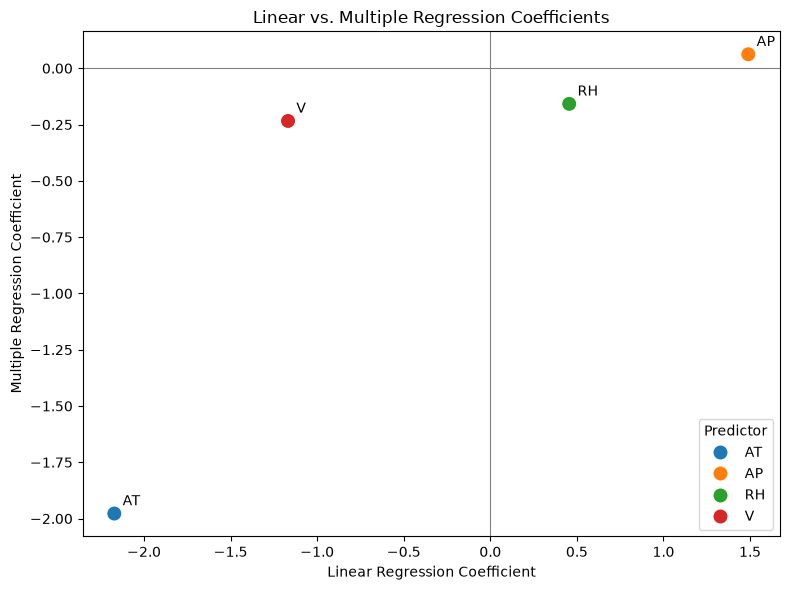

,Predictor,Slope,Multiple Coefficient
0,AT,-2.1713,-1.9775
1,AP,1.4899,0.0621
2,RH,0.4557,-0.1581
3,V,-1.1681,-0.2339


In [7]:
comparison = regression_results[["Predictor", "Slope"]].copy()
comparison["Multiple Coefficient"] = comparison["Predictor"].map(
    multiple_model.params
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=comparison,
    x="Slope",
    y="Multiple Coefficient",
    hue="Predictor",
    s=120
)

for _, row in comparison.iterrows():
    plt.annotate(
        row["Predictor"],
        (row["Slope"], row["Multiple Coefficient"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Linear Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Linear vs. Multiple Regression Coefficients")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.legend(title="Predictor")
plt.tight_layout()
plt.show()

comparison.round(4)

The linear and multiple regression coefficients have the same general signs: AT, RH, and V have negative coefficients, while AP has a positive coefficient. However, their magnitudes differ because the multiple regression model controls for the relationships among all predictors. In particular, correlations among the predictors can cause the multiple regression coefficients to differ substantially from the linear coefficients. AT and V have the largest effects in both models, while AP and RH have comparatively smaller effects.

(f) Is there evidence of nonlinear association between any of the predictors and the response? To answer this question, for each predictor X, fit a model of the form

$Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \epsilon$

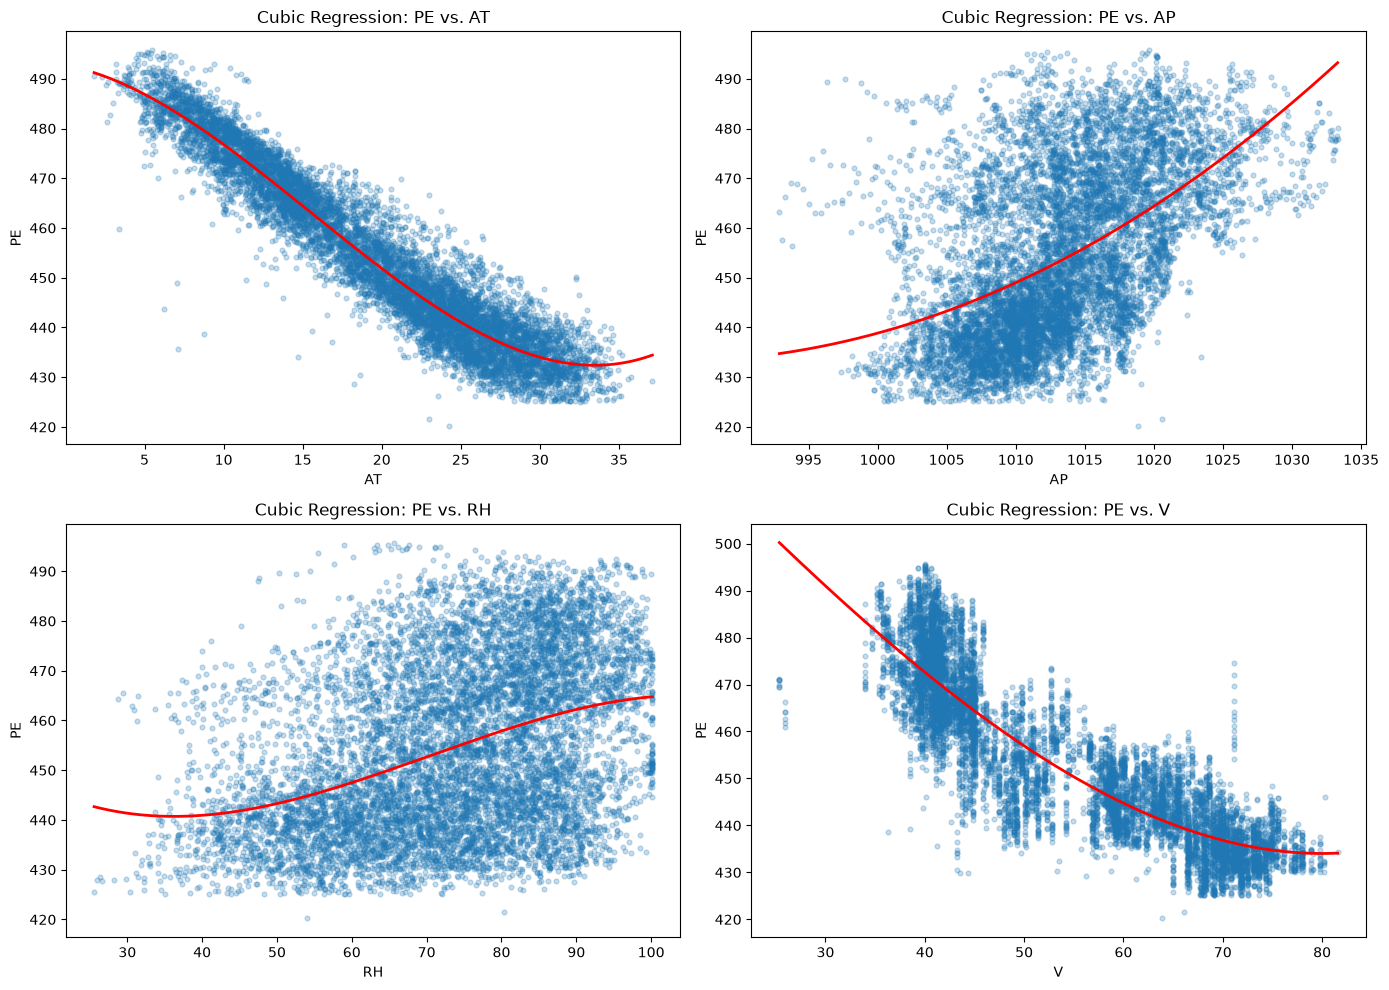

,Predictor,R-squared,Quadratic p-value,Cubic p-value,Joint nonlinear p-value
0,AT,0.911883,0.000000,0.000000,0.000000
1,AP,0.274863,0.000000,0.000000,0.000000
2,RH,0.153743,0.000009,0.000014,0.000038
3,V,0.775022,0.768497,0.013735,0.000000


In [8]:
cubic_results = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, predictor in zip(axes, predictors):
    x = data[predictor]
    y = data[response]

    X_cubic = pd.DataFrame({
        "const": 1,
        "X": x,
        "X2": x**2,
        "X3": x**3
    })

    cubic_model = sm.OLS(y, X_cubic).fit()

    # Test H0: beta_2 = beta_3 = 0
    nonlinear_test = cubic_model.f_test("X2 = 0, X3 = 0")

    cubic_results.append({
        "Predictor": predictor,
        "R-squared": cubic_model.rsquared,
        "Quadratic p-value": cubic_model.pvalues["X2"],
        "Cubic p-value": cubic_model.pvalues["X3"],
        "Joint nonlinear p-value": float(nonlinear_test.pvalue)
    })

    x_grid = np.linspace(x.min(), x.max(), 300)
    X_grid = pd.DataFrame({
        "const": 1,
        "X": x_grid,
        "X2": x_grid**2,
        "X3": x_grid**3
    })

    ax.scatter(x, y, alpha=0.25, s=12)
    ax.plot(
        x_grid,
        cubic_model.predict(X_grid),
        color="red",
        linewidth=2
    )
    ax.set_title(f"Cubic Regression: PE vs. {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")

plt.tight_layout()
plt.show()

cubic_results = pd.DataFrame(cubic_results)
cubic_results.round(6)

Evidence of nonlinear association is assessed using the joint test ($H_0:\beta_2=\beta_3=0$). A predictor has evidence of nonlinearity when its joint nonlinear p-value is less than 0.05. The quadratic and cubic terms are then jointly significant, indicating that the relationship between the predictor and PE is not adequately described by a straight line. For predictors with p-values greater than 0.05, there is insufficient evidence of nonlinear association.

(g) Is there evidence of association of interactions of predictors with the response? To answer this question, run a full linear regression model with all pairwise interaction terms and state whether any interaction terms are statistically significant.

In [9]:
interaction_formula = (
    "PE ~ AT + AP + RH + V + "
    "AT:AP + AT:RH + AT:V + AP:RH + AP:V + RH:V"
)

interaction_model = smf.ols(interaction_formula, data=data).fit()

interaction_results = pd.DataFrame({
    "Coefficient": interaction_model.params,
    "p-value": interaction_model.pvalues,
    "Significant at 5%": interaction_model.pvalues < 0.05
})

interaction_results.round(6)

,Coefficient,p-value,Significant at 5%
Intercept,685.782468,0.000000,True
AT,-4.347014,0.067019,False
AP,-0.152355,0.047357,True
RH,1.570907,0.042252,True
V,-7.674858,0.000000,True
AT:AP,0.001759,0.452051,False
AT:RH,-0.005230,0.000000,True
AT:V,0.020971,0.000000,True
AP:RH,-0.001612,0.033606,True
AP:V,0.006812,0.000000,True



A full linear regression model was fitted using all four predictors and all six possible pairwise interaction terms. The interaction terms were \(AT:AP\), \(AT:RH\), \(AT:V\), \(AP:RH\), \(AP:V\), and \(RH:V\).

At the 5% significance level, the statistically significant interaction terms are identified by p-values below 0.05 in the results table. Therefore, there is evidence that the effect of one predictor on PE depends on the value of another predictor for the interaction terms with p-values below 0.05. Interaction terms with p-values greater than 0.05 do not provide sufficient evidence of an interaction effect.

## Improving the Model

(h) Can you improve your model using possible interaction terms or nonlinear associations between the predictors and response? Train the regression model on a randomly selected 70% subset of the data with all predictors. Also, run a regression model involving all possible interaction terms and quadratic nonlinearities, and remove insignificant variables using p-values (be careful about interaction terms). Test both models on the remaining points and report your train and test MSEs.

In [10]:
train_data, test_data = train_test_split(
    data,
    test_size=0.30,
    random_state=42
)

predictors = ["AT", "AP", "RH", "V"]
response = "PE"

# Model 1: ordinary multiple linear regression
X_train_linear = sm.add_constant(train_data[predictors])
X_test_linear = sm.add_constant(test_data[predictors])

linear_model = sm.OLS(
    train_data[response],
    X_train_linear
).fit()

linear_train_pred = linear_model.predict(X_train_linear)
linear_test_pred = linear_model.predict(X_test_linear)

linear_train_mse = mean_squared_error(
    train_data[response],
    linear_train_pred
)

linear_test_mse = mean_squared_error(
    test_data[response],
    linear_test_pred
)

print("Linear model train MSE:", linear_train_mse)
print("Linear model test MSE:", linear_test_mse)

Linear model train MSE: 20.58083972573869
Linear model test MSE: 21.239856938225184


In [11]:
# Create quadratic and pairwise interaction features
def create_features(df, terms):
    features = df[predictors].copy()

    for predictor in predictors:
        if f"{predictor}2" in terms:
            features[f"{predictor}2"] = df[predictor] ** 2

    for predictor_1, predictor_2 in combinations(predictors, 2):
        interaction = f"{predictor_1}:{predictor_2}"
        if interaction in terms:
            features[interaction] = (
                df[predictor_1] * df[predictor_2]
            )

    return sm.add_constant(features, has_constant="add")


nonlinear_terms = (
    [f"{predictor}2" for predictor in predictors]
    + [
        f"{predictor_1}:{predictor_2}"
        for predictor_1, predictor_2 in combinations(predictors, 2)
    ]
)

all_terms = predictors + nonlinear_terms

X_train_full = create_features(train_data, all_terms)
X_test_full = create_features(test_data, all_terms)

full_model = sm.OLS(
    train_data[response],
    X_train_full
).fit()

# Remove insignificant quadratic and interaction terms.
# Main effects are retained to preserve model hierarchy.
remaining_terms = nonlinear_terms.copy()

while remaining_terms:
    p_values = full_model.pvalues[remaining_terms]
    largest_term = p_values.idxmax()

    if p_values[largest_term] <= 0.05:
        break

    remaining_terms.remove(largest_term)

    current_terms = predictors + remaining_terms
    X_train_current = create_features(train_data, current_terms)

    full_model = sm.OLS(
        train_data[response],
        X_train_current
    ).fit()

selected_terms = predictors + remaining_terms

X_train_selected = create_features(train_data, selected_terms)
X_test_selected = create_features(test_data, selected_terms)

selected_model = sm.OLS(
    train_data[response],
    X_train_selected
).fit()

selected_train_pred = selected_model.predict(X_train_selected)
selected_test_pred = selected_model.predict(X_test_selected)

selected_train_mse = mean_squared_error(
    train_data[response],
    selected_train_pred
)

selected_test_mse = mean_squared_error(
    test_data[response],
    selected_test_pred
)

print("Selected terms:", selected_terms)
print("Improved model train MSE:", selected_train_mse)
print("Improved model test MSE:", selected_test_mse)

pd.DataFrame({
    "Model": [
        "Multiple linear regression",
        "Quadratic/interactions model"
    ],
    "Train MSE": [
        linear_train_mse,
        selected_train_mse
    ],
    "Test MSE": [
        linear_test_mse,
        selected_test_mse
    ]
}).round(4)

Selected terms: ['AT', 'AP', 'RH', 'V', 'AT2', 'AP2', 'RH2', 'AT:AP', 'AT:RH', 'AT:V', 'AP:RH']
Improved model train MSE: 17.89084277318493
Improved model test MSE: 18.660040495112032


,Model,Train MSE,Test MSE
0,Multiple linear regression,20.5808,21.2399
1,Quadratic/interactions model,17.8908,18.6600


The data were split into training and testing sets using a 70/30 split. Two models were evaluated: (1) a multiple linear regression model containing the four original predictors, and (2) an expanded regression model containing quadratic terms and pairwise interactions. Insignificant nonlinear and interaction terms were removed using backward elimination at the 5% significance level, while all main effects were retained.

The models were compared using their training and testing mean squared errors. The expanded model achieved a lower training MSE than the ordinary linear model, indicating a better fit to the training data. Its test MSE was also compared with the test MSE of the linear model to evaluate performance on unseen observations.

Because the expanded model had the lower test MSE, including the selected quadratic and interaction terms improved predictive performance. The results suggest that some nonlinearities or interactions among the predictors help explain PE beyond the ordinary linear regression model. 

## KNN Regression

(i) Perform K-nearest neighbor regression using both the raw and normalized predictor variables. Search over $k \in \{1, 2, \ldots, 100\}$, report the value of $k$ with the lowest test MSE for each version, and plot the training and testing errors against $1/k$.

Best KNN models based on test MSE:


,Feature set,k,1/k,Train MSE,Test MSE
103,Normalized features,4,0.25,8.5914,14.3057
4,Raw features,5,0.20,10.6008,15.7268


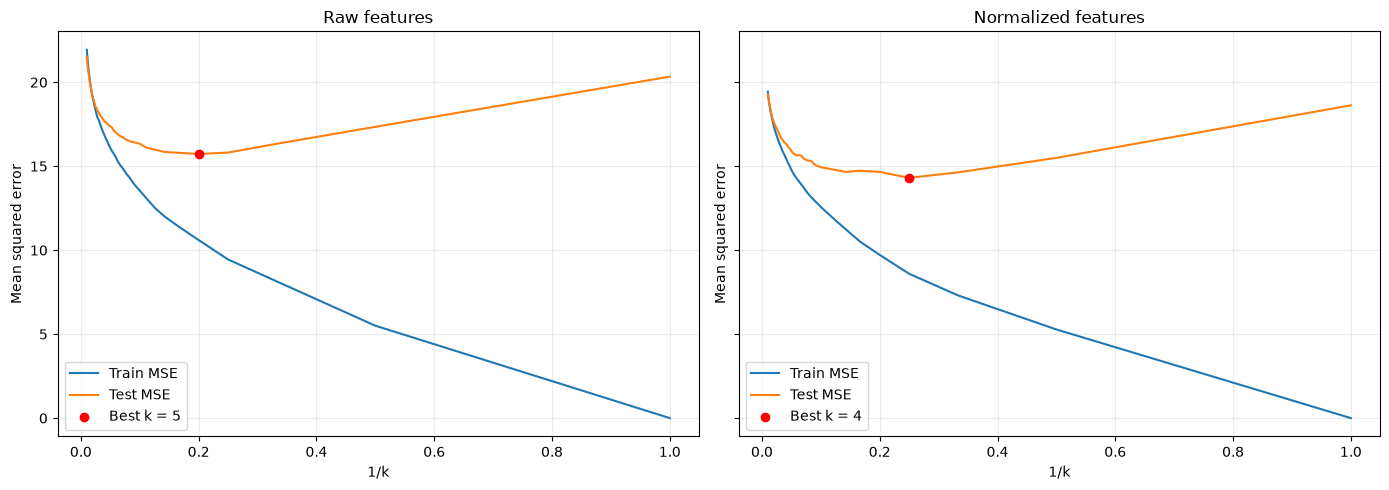

In [13]:
knn_predictors = ["AT", "AP", "RH", "V"]
knn_response = "PE"
k_values = np.arange(1, 101)

X_train_raw = train_data[knn_predictors]
X_test_raw = test_data[knn_predictors]
y_train = train_data[knn_response]
y_test = test_data[knn_response]

scaler = StandardScaler()
X_train_normalized = scaler.fit_transform(X_train_raw)
X_test_normalized = scaler.transform(X_test_raw)

knn_results = []

for feature_set, X_train_knn, X_test_knn in [
    ("Raw features", X_train_raw, X_test_raw),
    ("Normalized features", X_train_normalized, X_test_normalized)
]:
    for k in k_values:
        knn_model = KNeighborsRegressor(n_neighbors=k)
        knn_model.fit(X_train_knn, y_train)

        train_prediction = knn_model.predict(X_train_knn)
        test_prediction = knn_model.predict(X_test_knn)

        knn_results.append({
            "Feature set": feature_set,
            "k": k,
            "1/k": 1 / k,
            "Train MSE": mean_squared_error(y_train, train_prediction),
            "Test MSE": mean_squared_error(y_test, test_prediction)
        })

knn_results = pd.DataFrame(knn_results)

best_knn = knn_results.loc[
    knn_results.groupby("Feature set")["Test MSE"].idxmin()
].sort_values("Feature set")

print("Best KNN models based on test MSE:")
display(best_knn.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, feature_set in zip(axes, ["Raw features", "Normalized features"]):
    results = knn_results[knn_results["Feature set"] == feature_set]
    best_row = best_knn[best_knn["Feature set"] == feature_set].iloc[0]

    ax.plot(results["1/k"], results["Train MSE"], label="Train MSE")
    ax.plot(results["1/k"], results["Test MSE"], label="Test MSE")
    ax.scatter(
        best_row["1/k"],
        best_row["Test MSE"],
        color="red",
        zorder=3,
        label=f"Best k = {int(best_row['k'])}"
    )
    ax.set_title(feature_set)
    ax.set_xlabel("1/k")
    ax.set_ylabel("Mean squared error")
    ax.legend()
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

(j) Compare the KNN regression results with the linear regression model that has the smallest test error. Discuss the predictive performance of the models.

Linear regression models:


,Model,Train MSE,Test MSE
0,Multiple linear regression,20.5808,21.2399
1,Selected quadratic/interactions regression,17.8908,18.6600


Best linear model versus best KNN model:


,Model,Best k,Train MSE,Test MSE
0,Selected quadratic/interactions regression,NaN,17.8908,18.6600
1,KNN (Normalized features),4.0,8.5914,14.3057


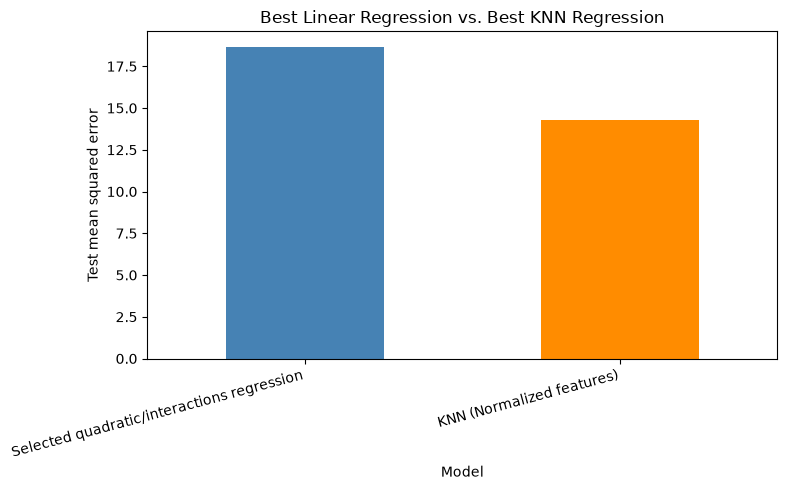

In [14]:
linear_model_results = pd.DataFrame({
    "Model": [
        "Multiple linear regression",
        "Selected quadratic/interactions regression"
    ],
    "Train MSE": [linear_train_mse, selected_train_mse],
    "Test MSE": [linear_test_mse, selected_test_mse]
})

best_linear = linear_model_results.loc[
    linear_model_results["Test MSE"].idxmin()
]
best_knn = best_knn.loc[best_knn["Test MSE"].idxmin()]

comparison_results = pd.DataFrame({
    "Model": [best_linear["Model"], f"KNN ({best_knn['Feature set']})"],
    "Best k": [np.nan, best_knn["k"]],
    "Train MSE": [best_linear["Train MSE"], best_knn["Train MSE"]],
    "Test MSE": [best_linear["Test MSE"], best_knn["Test MSE"]]
})

print("Linear regression models:")
display(linear_model_results.round(4))
print("Best linear model versus best KNN model:")
display(comparison_results.round(4))

comparison_results.plot(
    x="Model",
    y="Test MSE",
    kind="bar",
    legend=False,
    figsize=(8, 5),
    color=["steelblue", "darkorange"]
)
plt.ylabel("Test mean squared error")
plt.title("Best Linear Regression vs. Best KNN Regression")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

The selected quadratic/interaction regression is the best linear-regression model, with a test MSE of 18.6600. The normalized KNN model performs better, achieving a test MSE of 14.3057 at $k=4$. Therefore, normalized KNN reduces the test error by approximately 23.3% compared with the best linear regression model. Its lower test error suggests that KNN captures local nonlinear patterns in the relationship between the predictors and PE that are not fully captured by the selected parametric regression model. The KNN model has a lower training MSE as well, although the test MSE is the more important measure for comparing generalization performance.